# Choosing a Model
We will find the most accurate machine learning model to use.

Load all dependancies

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import preprocessing
import pickle
from seaborn import regplot

Load variables from prior notebooks

In [2]:
df = pd.read_csv('/workspaces/2025SE_Gianfranco.M_CSAI/1. Data/csgo_round_snapshots.csv')
scaler = preprocessing.StandardScaler()
label_encoder = preprocessing.LabelEncoder() 
df['round_winner'] = label_encoder.fit_transform(df['round_winner'])
df['bomb_planted'] = label_encoder.fit_transform(df['bomb_planted'])
df['map'] = label_encoder.fit_transform(df['map'])

assign feature and target variables

In [3]:
X = df[['map','ct_money', 't_money', 'ct_players_alive', 't_players_alive', 'bomb_planted']]
y = df['round_winner']

this function will split our dataset into a 20/80 split as defined with 'test_size=0.2'

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Run standard scalar on data

In [5]:
scaler.fit(X_train)

StandardScaler()

### We will now need to train and test our machine learning model

In [6]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.6765
              precision    recall  f1-score   support

           0       0.68      0.65      0.66     12004
           1       0.68      0.70      0.69     12478

    accuracy                           0.68     24482
   macro avg       0.68      0.68      0.68     24482
weighted avg       0.68      0.68      0.68     24482

Decision Tree Accuracy: 0.7886
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     12004
           1       0.79      0.79      0.79     12478

    accuracy                           0.79     24482
   macro avg       0.79      0.79      0.79     24482
weighted avg       0.79      0.79      0.79     24482

Random Forest Accuracy: 0.8164
              precision    recall  f1-score   support

           0       0.81      0.81      0.81     12004
           1       0.82      0.82      0.82     12478

    accuracy                           0.82     24482
   macro avg       0.82      

Utilising the results from above, we can extract that the **Random Forest Classifier method is the most accurate**.

To further test this, we can look at a confusion matrix to see how many predictions were right and wrong.

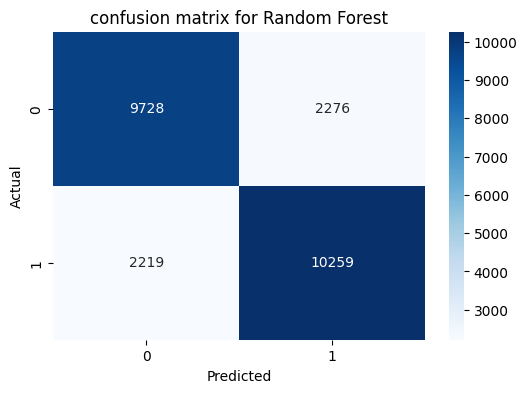

In [ ]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('confusion matrix for ' f'{model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

y_pred_rf = models["Random Forest"].predict(X_test)
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")

Not bad!!!! we will continue to develop this model. First, lets pickle and save the model and other functions.

In [8]:
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(models["Random Forest"], f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

with open('X_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)